# Baseline experiments for the diploma thesis
author: Lubojacky Jan (lubojjan@fel.cvut.cz)

In [1]:
import numpy as np
import polars as pl
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, cross_validate, cross_val_predict, train_test_split, cross_val_score
from sklearn.feature_selection import RFE
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, roc_auc_score, make_scorer
from sklearn.svm import SVC

import xgboost as xgb

import seaborn as sn
import matplotlib.pyplot as plt

# Loading & preprocessing the data

In [2]:
# loading data
RNA = pl.read_csv("data/200625_allRNA_fromRNAseq_annot_hg38.tsv", separator="\t")
circRNA = pl.read_csv("data/200625_circRNA_fromRNAseq_annot_hg19.tsv", separator="\t",  null_values=["NA"])
piRNA = pl.read_excel("data/piRNA_counts.xlsx", engine="xlsx2csv")
miRNA = pl.read_excel("data/final_all_samples_miRNA_seq.xlsx", engine="xlsx2csv")
sampleSheet = pl.read_excel("data/sample sheet for CVUT.xlsx", engine="xlsx2csv")

In [ ]:
# preprocessing the data
# drop columns with zero variance from RNA

In [3]:
# find names which are both in RNA and sample sheet
sampleSheet_names = sampleSheet["SAMPLE_NAME"].to_list()
RNA_names = RNA.columns

print(sampleSheet_names)
print(RNA_names)

# find names which are both in sampleSheet_names and RNA_names
common_names = list(set(sampleSheet_names) & set(RNA_names))
common_names.sort()
print("Number of common names: ", len(common_names))
print(common_names)

# show non-common names
print("Non-common names in RNA: ", list(set(RNA_names) - set(common_names)))

['N54_S14', 'N58_S18', 'N60_S15', 'N70_S16', 'N82_S1', 'N83_S3', 'N84_S4', 'N85_S19', 'N86_S13', 'N87_S20', 'NV1428_S3', 'NV911_S19', 'NV912_S20', 'V1776_S9', 'V2110_S16', 'V2224_S17', 'V2241_S15', 'V2248_S18', 'V2322_S20', 'V2414_S25', 'V630_S11', 'V1528_S12', 'V1860_S18', 'V2133_S43', 'V1505_S10', 'V1591_S14', 'V456_S4', 'V513_S16', 'V637_S21', 'V1874_S1', 'V777_S20', 'V1800_S1', 'V359_S3', 'V382_S22', 'V406_S18', 'V220_S6', 'V2286_S1', 'V716_S1', 'V806_S1', 'V888_S2', 'V956_S6', 'V125_S5', 'V1321_S4', 'V1788_S2', 'V1456_S13', 'V108_S5', 'V624_S15', 'V1048_S12', 'V2368_S3', 'V1565_S13', 'V1422_S6', 'V1708_S22', 'V1920_S14', 'V2089_S9', 'V2284_S4', 'V2378_S5', 'V553_S11', 'V1699_S2', 'V1742_S5', 'V1823_S7', 'V1834_S7', 'V2092_S3', 'V344_S16', 'V67_S6', 'V883_S4', 'V940_S8', 'V712_S22', 'V1279_S21', 'V148_S10', 'V2278_S19', 'V1857_S8', 'V1664_S23', 'V480_S7', 'V100_S45', 'V2115_S9', 'V538_S12', 'V76_S21', 'V839_S17', 'V1744_S46', 'V2147_S10', 'V2179_S11', 'V1441_S2', 'V1592_S5', 'V1689

**Create input data**
- each row in RNA_X is one sample
- and we have the labels for 3 classification tasks, binary disease, 3-class risk and 3-class mutation

In [107]:
a = np.random.randint(0, 100, size=(10, 5))
a[:, 3] = 1
a

array([[99, 51, 76,  1, 72],
       [20, 90, 47,  1, 88],
       [21, 23, 67,  1, 77],
       [12, 70, 42,  1, 14],
       [35, 94,  8,  1, 19],
       [77, 43, 28,  1, 88],
       [96, 42, 20,  1, 94],
       [14, 32, 64,  1, 72],
       [87, 43,  8,  1, 67],
       [65, 13, 12,  1, 87]])

In [120]:
a.var(axis=0)

array([1147.84,  652.09,  595.16,    0.  ,  726.76])

In [108]:
df_a = pl.DataFrame(a)
df_a

column_0,column_1,column_2,column_3,column_4
i64,i64,i64,i64,i64
99,51,76,1,72
20,90,47,1,88
21,23,67,1,77
12,70,42,1,14
35,94,8,1,19
77,43,28,1,88
96,42,20,1,94
14,32,64,1,72
87,43,8,1,67


In [119]:
df_a.var()

column_0,column_1,column_2,column_3,column_4
f64,f64,f64,f64,f64
1275.377778,724.544444,661.288889,0.0,807.511111


In [4]:
RNA_X = (RNA.lazy()         
         .select(common_names)
         .collect()).to_numpy().T

non_zero_var = RNA_X.var(axis=0) != 0

y = (sampleSheet.lazy()
    .filter(pl.col('SAMPLE_NAME').is_in(common_names))
    .sort("SAMPLE_NAME")
    .select(["1 disease", "2 risk", "3 mutations (SF3B1only_wt)"])
    .collect()).to_numpy()
y_disease, y_risk, y_mutation = y[:, 0] - 1, y[:, 1], y[:, 2] # -1 to make it 0/1 instead of 1/2

[[ 89 407   6 ...   0  96 165]
 [ 55 235   9 ...   0  55 159]
 [ 79 244  70 ...   0  85 136]
 ...
 [ 48 474  18 ...   3  37 210]
 [ 31 364  10 ...   0   2  21]
 [ 44 176   0 ...   8   0 112]]


**Data exploration / visualization with PCA**

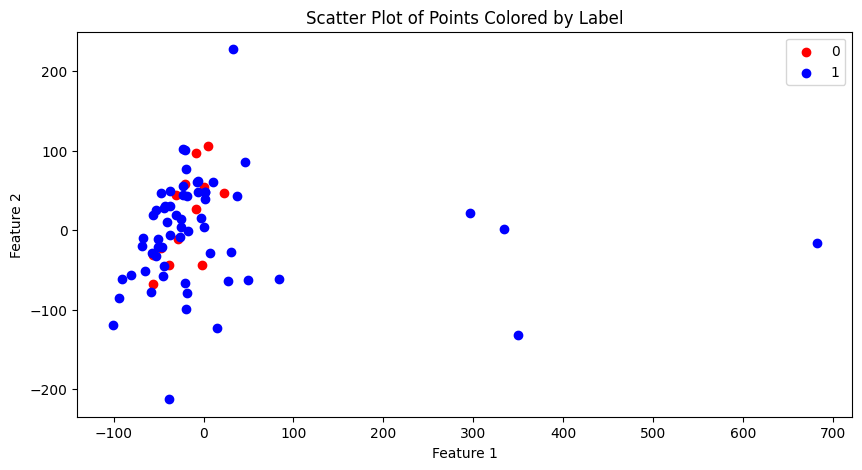

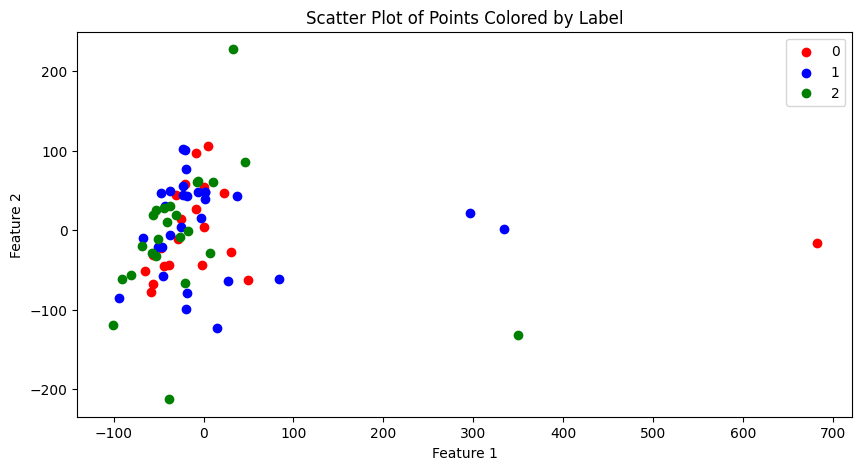

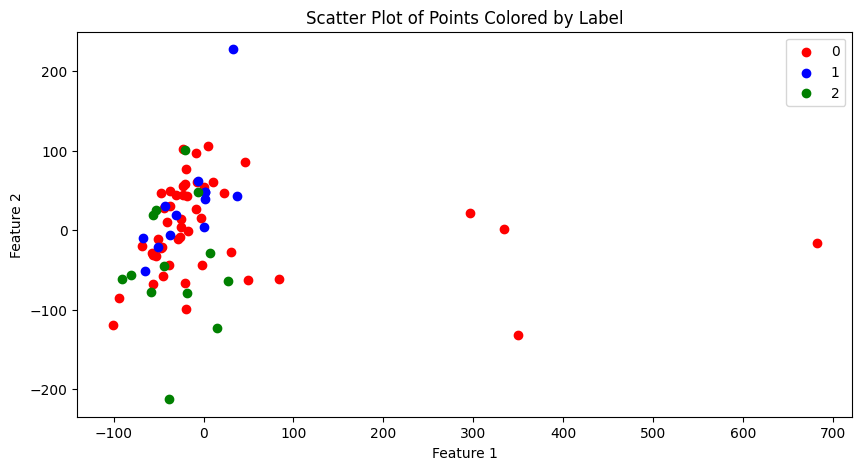

In [41]:
scaler = StandardScaler()
scaler.fit(RNA_X)
RNA_scaled = scaler.transform(RNA_X)

pca = PCA(n_components=2)
pca.fit(RNA_scaled)
RNA_pca = pca.transform(RNA_scaled)

def visualize_and_color_by_class(X, y):

    # split X by class and plot
    colors = ['red', 'blue', 'green', 'orange', 'purple', 'black', 'yellow']
    plt.figure(figsize=(10, 5))

    for i in range(len(np.unique(y))):
        X_i = X[y == i]
        plt.scatter(X_i[:, 0], X_i[:, 1], label=str(i), color=colors[i])

    # Add labels and legend
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title('Scatter Plot of Points Colored by Label')
    plt.legend()

    # Show the plot
    plt.show()

visualize_and_color_by_class(RNA_pca, y_disease)
visualize_and_color_by_class(RNA_pca, y_risk)
visualize_and_color_by_class(RNA_pca, y_mutation)


# KNN

In [42]:
def KNN_evaluation(X, y, verbose=True):

    # Instantiate a KNN classifier
    knn = KNeighborsClassifier()

    # Set up the parameter grid for GridSearchCV
    param_grid = {'n_neighbors': np.arange(1, 20)}

    # Define the scoring metrics
    scoring_metrics = {
        'accuracy': 'accuracy',
        'f1_macro': 'f1_macro',
        'f1_weighted': 'f1_weighted',
        # 'roc_auc_macro': make_scorer(roc_auc_score, multi_class='ovo', average='macro'),
        # 'roc_auc_weighted': make_scorer(roc_auc_score, multi_class='ovo', average='weighted')
    }

    # Use GridSearchCV to find the best k
    grid_search = GridSearchCV(knn, param_grid, scoring=scoring_metrics, cv=5, refit='accuracy', n_jobs=-1)
    grid_search.fit(X, y)

    # Get the results of the grid search
    best_k = grid_search.best_params_['n_neighbors']

    # Train the model with the best k
    best_knn = KNeighborsClassifier(n_neighbors=best_k)
    # best_knn.fit(X, y)

    # Evaluate the model using cross-validation
    cv_results = cross_validate(
        best_knn, 
        X, 
        y, 
        cv=5, 
        scoring=scoring_metrics,
        n_jobs=-1
    )

    if verbose:
        # Display the results
        print("\nCross Validation Results:")
        print(f'Accuracy: {cv_results["test_accuracy"].mean():.2f} +/- {cv_results["test_accuracy"].std():.2f}')
        print(f'F1 Macro: {cv_results["test_f1_macro"].mean():.2f} +/- {cv_results["test_f1_macro"].std():.2f}')
        print(f'F1 Weighted: {cv_results["test_f1_weighted"].mean():.2f} +/- {cv_results["test_f1_weighted"].std():.2f}')
        # print(f'ROC AUC Macro: {cv_results["test_roc_auc_macro"].mean():.2f} +/- {cv_results["test_roc_auc_macro"].std():.2f}')
        # print(f'ROC AUC Weighted: {cv_results["test_roc_auc_weighted"].mean():.2f} +/- {cv_results["test_roc_auc_weighted"].std():.2f}')

    return cv_results["test_f1_weighted"].mean() + cv_results["test_accuracy"].mean() + cv_results["test_f1_macro"].mean()

In [45]:
print("\nKNN evaluation on all RNA for disease:")
_ = KNN_evaluation(RNA_X, y_disease)
print("\nKNN evaluation on all RNA for risk:")
_ = KNN_evaluation(RNA_X, y_risk)
print("\nKNN evaluation on all RNA for mutation:")
_ = KNN_evaluation(RNA_X, y_mutation)


KNN evaluation on all RNA for disease:

Cross Validation Results:
Accuracy: 0.83 +/- 0.07
F1 Macro: 0.65 +/- 0.13
F1 Weighted: 0.81 +/- 0.08

KNN evaluation on all RNA for risk:

Cross Validation Results:
Accuracy: 0.42 +/- 0.13
F1 Macro: 0.39 +/- 0.12
F1 Weighted: 0.40 +/- 0.11

KNN evaluation on all RNA for mutation:

Cross Validation Results:
Accuracy: 0.65 +/- 0.05
F1 Macro: 0.31 +/- 0.10
F1 Weighted: 0.54 +/- 0.06


## We can increase the accuracy by a significant margin using PCA to reduce the dimensionality of the data

**NOTE:** the [MoGCN](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC8847688/) paper reports that using a more sophisticated DR method such as Autoencoders further increases the accuracy of the model, especially as the dimensionality of the training data increases, we could also try that later


**NOTE 2:** We would also probably get better results by tuning the number of neighbours and PCA features simultaneously, but designing the best possible kNN model is not the goal of this thesis


In [108]:
scaler = StandardScaler()
scaler.fit(RNA_X)
RNA_scaled = scaler.transform(RNA_X)

best_PCA_components_disease = 1
best_disease_score = 0
best_PCA_components_risk = 1
best_risk_score = 0
best_PCA_components_mutation = 1
best_mutation_score = 0

for i in range(1, 30):
    pca = PCA(n_components=i)
    pca.fit(RNA_scaled)
    RNA_pca = pca.transform(RNA_scaled)

    score_d = KNN_evaluation(RNA_pca, y_disease, verbose=False)
    score_r = KNN_evaluation(RNA_pca, y_risk, verbose=False)
    score_m = KNN_evaluation(RNA_pca, y_mutation, verbose=False)

    if score_d > best_disease_score:
        best_PCA_components_disease = i
        best_disease_score = score_d
    if score_r > best_risk_score:
        best_PCA_components_risk = i
        best_risk_score = score_r
    if score_m > best_mutation_score:
        best_PCA_components_mutation = i
        best_mutation_score = score_m

print("Best number of PCA components for disease: ", best_PCA_components_disease)
print("Best number of PCA components for risk: ", best_PCA_components_risk)
print("Best number of PCA components for mutation: ", best_PCA_components_mutation)

Best number of PCA components for disease:  12
Best number of PCA components for risk:  29
Best number of PCA components for mutation:  11


In [36]:
print("RNA all evaluation, on PCA reduced data (disease):")
# fit the KNN model again on the PCA-transformed data
pca = PCA(n_components=12)
pca.fit(RNA_scaled)
RNA_pca = pca.transform(RNA_scaled)

_ = KNN_evaluation(RNA_pca, y_disease)

print("RNA all evaluation, on PCA reduced data (disease):")
# fit the KNN model again on the PCA-transformed data
pca = PCA(n_components=29)
pca.fit(RNA_scaled)
RNA_pca = pca.transform(RNA_scaled)

_ = KNN_evaluation(RNA_pca, y_risk)

print("RNA all evaluation, on PCA reduced data (disease):")
# fit the KNN model again on the PCA-transformed data
pca = PCA(n_components=12)
pca.fit(RNA_scaled)
RNA_pca = pca.transform(RNA_scaled)

_ = KNN_evaluation(RNA_pca, y_mutation)

RNA all evaluation, on PCA reduced data (disease):


NameError: name 'KNN_evaluation' is not defined

# SVM
- as the number of features is very high we will use PCA here from the start to reduce the dimensionality of the data and speed up the training & parameter tuning
- we also tried two different kernels, linear and rbf, but the linear kernel performed much better in all cases

In [6]:
def SVM_evaluation(X, y, verbose=True):

    # Instantiate a SVM classifier
    svm = SVC(kernel='rbf', probability=True)

    # Set up the parameter grid for GridSearchCV
    param_grid = {'C': np.linspace(10**-4, 10, 10), 'gamma': np.linspace(10**-4, 10, 10)}

    # Define the scoring metrics
    scoring_metrics = {
        'accuracy': 'accuracy',
        'f1_macro': 'f1_macro',
        'f1_weighted': 'f1_weighted',
        # 'roc_auc_macro': make_scorer(roc_auc_score, multi_class='ovo', average='macro'),
        # 'roc_auc_weighted': make_scorer(roc_auc_score, multi_class='ovo', average='weighted')
    }

    X = (X - X.mean(axis=0)) / X.std(axis=0)

    # Use GridSearchCV to find the best k
    grid_search = GridSearchCV(svm, param_grid, scoring=scoring_metrics, cv=5, refit='accuracy', n_jobs=-1)
    grid_search.fit(X, y)

    # Get the results of the grid search
    best_C = grid_search.best_params_['C']
    best_gamma = grid_search.best_params_['gamma']

    # Train the model with the best k
    best_svm = SVC(kernel='rbf', probability=True, C=best_C, gamma=best_gamma)
    # best_svm.fit(X, y)

    if verbose:
        print(f'Best C: {best_C}')
        print(f'Best gamma: {best_gamma}')

    # Evaluate the model using cross-validation
    cv_results = cross_validate(
        best_svm, 
        X, 
        y, 
        cv=5, 
        scoring=scoring_metrics,
        n_jobs=-1
    )

    if verbose:
        # Display the results
        print("\nCross Validation Results:")
        print(f'Accuracy: {cv_results["test_accuracy"].mean():.2f} +/- {cv_results["test_accuracy"].std():.2f}')
        print(f'F1 Macro: {cv_results["test_f1_macro"].mean():.2f} +/- {cv_results["test_f1_macro"].std():.2f}')
        print(f'F1 Weighted: {cv_results["test_f1_weighted"].mean():.2f} +/- {cv_results["test_f1_weighted"].std():.2f}')


    return cv_results["test_f1_weighted"].mean() + cv_results["test_accuracy"].mean() + cv_results["test_f1_macro"].mean()

In [81]:
data = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]])

data.mean(axis=1)

print(data.mean(axis=0))
print(data.std(axis=0))

data = (data - data.mean(axis=0)) / data.std(axis=0)

print(data.mean(axis=0))
print(data.std(axis=0))
data
# data = (data - np.mean(data, axis=0)) / np.std(data, axis=0)


[4. 5. 6.]
[2.44948974 2.44948974 2.44948974]
[0. 0. 0.]
[1. 1. 1.]


array([[-1.22474487, -1.22474487, -1.22474487],
       [ 0.        ,  0.        ,  0.        ],
       [ 1.22474487,  1.22474487,  1.22474487]])

In [85]:
def SVM_evaluation_linear(X, y, verbose=True):
    # Instantiate a SVM classifier
    svm = SVC(kernel='linear', probability=True)

    # remove columns with zero variance
    X = X[:, np.std(X, axis=0) != 0]

    # normalize X by columns
    X = (X - X.mean(axis=0)) / X.std(axis=0)

    # Set up the parameter grid for GridSearchCV
    param_grid = {'C': np.logspace(-2, 2, 20)}

    # Define the scoring metrics
    scoring_metrics = {
        'accuracy': 'accuracy',
        'f1_macro': 'f1_macro',
        'f1_weighted': 'f1_weighted',
    }

    # Use GridSearchCV to find the best k
    grid_search = GridSearchCV(svm, param_grid, scoring=scoring_metrics, cv=5, refit='f1_weighted', n_jobs=-1)
    grid_search.fit(X, y)

    # Get the results of the grid search
    best_C = grid_search.best_params_['C']

    if verbose:
        print(f'Best C: {best_C}')

    # Train the model with the best k
    best_svm = SVC(kernel='linear', probability=True, C=best_C)
    # best_svm.fit(X, y)

    # Evaluate the model using cross-validation
    cv_results = cross_validate(
        best_svm, 
        X, 
        y, 
        cv=5, 
        scoring=scoring_metrics,
        n_jobs=-1
    )

    # Display the results
    print("\nCross Validation Results:")
    print(f'Accuracy: {cv_results["test_accuracy"].mean():.2f} +/- {cv_results["test_accuracy"].std():.2f}')
    print(f'F1 Macro: {cv_results["test_f1_macro"].mean():.2f} +/- {cv_results["test_f1_macro"].std():.2f}')
    print(f'F1 Weighted: {cv_results["test_f1_weighted"].mean():.2f} +/- {cv_results["test_f1_weighted"].std():.2f}')

    return cv_results["test_f1_weighted"].mean() + cv_results["test_accuracy"].mean() + cv_results["test_f1_macro"].mean()
                          

In [74]:
print("RNA all evaluation (disease):")
_ = SVM_evaluation(RNA_X, y_disease, verbose=True)
print("RNA all evaluation (mutation):")
_ = SVM_evaluation(RNA_X, y_mutation, verbose=True)
print("RNA all evaluation (risk):")
_ = SVM_evaluation(RNA_X, y_risk, verbose=True)

RNA all evaluation (disease):
Best C: 0.0001
Best gamma: 0.0001

Cross Validation Results:
Accuracy: 0.82 +/- 0.03
F1 Macro: 0.45 +/- 0.01
F1 Weighted: 0.75 +/- 0.04
RNA all evaluation (mutation):
Best C: 0.0001
Best gamma: 0.0001

Cross Validation Results:
Accuracy: 0.65 +/- 0.03
F1 Macro: 0.26 +/- 0.01
F1 Weighted: 0.51 +/- 0.03
RNA all evaluation (risk):
Best C: 0.0001
Best gamma: 0.0001

Cross Validation Results:
Accuracy: 0.39 +/- 0.03
F1 Macro: 0.19 +/- 0.01
F1 Weighted: 0.22 +/- 0.03


In [91]:
print("\nRNA all evaluation (disease):")
_ = SVM_evaluation_linear(RNA_X, y_disease, verbose=True)
print("\nRNA all evaluation (mutation):")
_ = SVM_evaluation_linear(RNA_X, y_mutation, verbose=True)
print("\nRNA all evaluation (risk):")
_ = SVM_evaluation_linear(RNA_X, y_risk, verbose=True)


RNA all evaluation (disease):
Best C: 0.01

Cross Validation Results:
Accuracy: 0.86 +/- 0.06
F1 Macro: 0.66 +/- 0.19
F1 Weighted: 0.83 +/- 0.09

RNA all evaluation (mutation):
Best C: 0.01

Cross Validation Results:
Accuracy: 0.66 +/- 0.04
F1 Macro: 0.40 +/- 0.08
F1 Weighted: 0.57 +/- 0.04

RNA all evaluation (risk):
Best C: 0.01

Cross Validation Results:
Accuracy: 0.57 +/- 0.15
F1 Macro: 0.55 +/- 0.19
F1 Weighted: 0.56 +/- 0.17


# PCA + SVM
- again we can see that PCA helps us to achieve better results, especially for the 3-class mutation and risk classification tasks
- this would suggest that a lot of these features are redundant and we could probably achieve similar results with a much smaller number of features via feature selection
- compared to the kNN model the SVM model is more stable, the variance of the fits is much lower
- the performance is
    - slightly worse on the disease task
    - better on the risk task
    - worse on the mutation task

In [42]:
print(RNA_X.shape)

scaler = StandardScaler()
scaler.fit(RNA_X)
RNA_scaled = scaler.transform(RNA_X)

print(RNA_scaled.shape)

pca = PCA(n_components=5, svd_solver='auto')
pca.fit(RNA_scaled)
RNA_pca = pca.transform(RNA_scaled)

print(RNA_pca.shape)

(74, 58216)
(74, 58216)
(74, 5)


In [ ]:
print("RNA_pca evaluation, disease task")
_ = SVM_evaluation_linear(RNA_pca, y_disease, verbose=True)
print("RNA_pca evalutation, mutation task")
_ = SVM_evaluation_linear(RNA_pca, y_mutation, verbose=True)
print("RNA_pca evaluation, risk task")
_ = SVM_evaluation_linear(RNA_pca, y_risk, verbose=True)

In [44]:
np.logspace(-4, 2, 10)

array([1.00000000e-04, 4.64158883e-04, 2.15443469e-03, 1.00000000e-02,
       4.64158883e-02, 2.15443469e-01, 1.00000000e+00, 4.64158883e+00,
       2.15443469e+01, 1.00000000e+02])

In [79]:
print("RNA_pca evaluation, disease task")
_ = SVM_evaluation(RNA_pca, y_disease, verbose=True)
print("RNA_pca evalutation, mutation task")
_ = SVM_evaluation(RNA_pca, y_mutation, verbose=True)
print("RNA_pca evaluation, risk task")
_ = SVM_evaluation(RNA_pca, y_risk, verbose=True)

RNA_pca evaluation, disease task
Best C: 5.5556
Best gamma: 0.0001

Cross Validation Results:
Accuracy: 0.91 +/- 0.09
F1 Macro: 0.79 +/- 0.22
F1 Weighted: 0.89 +/- 0.12
RNA_pca evalutation, mutation task
Best C: 3.3334
Best gamma: 0.0001

Cross Validation Results:
Accuracy: 0.69 +/- 0.08
F1 Macro: 0.46 +/- 0.15
F1 Weighted: 0.64 +/- 0.10
RNA_pca evaluation, risk task
Best C: 1.1112
Best gamma: 0.0001

Cross Validation Results:
Accuracy: 0.47 +/- 0.04
F1 Macro: 0.42 +/- 0.06
F1 Weighted: 0.44 +/- 0.05


## SVMs with recursive feature selection

In [93]:
# C is best C from previous runs
svc_lin = SVC(kernel='linear', C=1.0, probability=True)

svm_rfe = RFE(estimator=svc_lin, n_features_to_select=100, step=100)

svm_rfe.fit(RNA_X, y_disease)

print(svm_rfe.support_)
print(svm_rfe.ranking_)

RNA_X_best100 = RNA_X[:, svm_rfe.support_]

SVM_evaluation_linear(RNA_X_best100, y_disease, verbose=True)

[False False False ... False False False]
[161 245 306 ... 309 351 244]
Best C: 0.11288378916846889

Cross Validation Results:
Accuracy: 0.95 +/- 0.05
F1 Macro: 0.90 +/- 0.11
F1 Weighted: 0.94 +/- 0.06


2.7868944099378883

In [102]:
# C is best C from previous runs
svc_lin = SVC(kernel='linear', C=1.0)

svm_rfe = RFE(estimator=svc_lin, n_features_to_select=100, step=500)

# remove columns with zero variance
RNA_X = RNA_X[:, np.std(RNA_X, axis=0) != 0]
RNA_X_norm = (RNA_X - RNA_X.mean(axis=0)) / RNA_X.std(axis=0)

svm_rfe.fit(RNA_X_norm, y_risk)

print(np.where(svm_rfe.support_ == True)[0])
print(svm_rfe.ranking_)

RNA_X_best100 = RNA_X_norm[:, svm_rfe.support_]

SVM_evaluation_linear(RNA_X_best100, y_risk, verbose=True)

Best C: 0.01

Cross Validation Results:
Accuracy: 0.97 +/- 0.03
F1 Macro: 0.97 +/- 0.03
F1 Weighted: 0.97 +/- 0.03


2.916305599162742

In [104]:
# C is best C from previous runs
svc_lin = SVC(kernel='linear', C=1.0, probability=True)

svm_rfe = RFE(estimator=svc_lin, n_features_to_select=100, step=500)

svm_rfe.fit(RNA_X_norm, y_mutation)

print(svm_rfe.support_)
print(svm_rfe.ranking_)

RNA_X_best100 = RNA_X_norm[:, svm_rfe.support_]

SVM_evaluation_linear(RNA_X_best100, y_mutation, verbose=True)

[False False False ... False False False]
[ 46 111  94 ...  14  41  74]
Best C: 0.01

Cross Validation Results:
Accuracy: 0.97 +/- 0.05
F1 Macro: 0.96 +/- 0.08
F1 Weighted: 0.97 +/- 0.06


2.902707070707071

# XGBoost

In [ ]:
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, cross_validate

def XGBoost_evaluation(X, y, verbose=True):
    # Instantiate an XGBoost classifier
    xgb = XGBClassifier(objective='multi:softmax', num_class=len(np.unique(y)))

    # Set up the parameter grid for GridSearchCV
    param_grid = {
        'learning_rate': [0.01, 0.1, 0.2],
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 4, 5],
    }

    # Define the scoring metrics
    scoring_metrics = {
        'accuracy': 'accuracy',
        'f1_macro': 'f1_macro',
        'f1_weighted': 'f1_weighted',
    }

    # Use GridSearchCV to find the best parameters
    grid_search = GridSearchCV(xgb, param_grid, scoring=scoring_metrics, cv=5, refit='f1_weighted', n_jobs=-1)
    grid_search.fit(X, y)

    # Get the results of the grid search
    best_params = grid_search.best_params_

    if verbose:
        print(f'Best Parameters: {best_params}')

    # Train the model with the best parameters
    best_xgb = XGBClassifier(objective='multi:softmax', num_class=len(np.unique(y)), **best_params)

    # Evaluate the model using cross-validation
    cv_results = cross_validate(
        best_xgb, 
        X, 
        y, 
        cv=5, 
        scoring=scoring_metrics,
        n_jobs=-1
    )

    # Display the results
    print("\nCross Validation Results:")
    print(f'Accuracy: {cv_results["test_accuracy"].mean():.2f} +/- {cv_results["test_accuracy"].std():.2f}')
    print(f'F1 Macro: {cv_results["test_f1_macro"].mean():.2f} +/- {cv_results["test_f1_macro"].std():.2f}')
    print(f'F1 Weighted: {cv_results["test_f1_weighted"].mean():.2f} +/- {cv_results["test_f1_weighted"].std():.2f}')


# Logistic regression

In [46]:
# Standardize the train and test sample
scaler = StandardScaler()
X_std = scaler.fit_transform(RNA_X)

# Perform GridSearchCV to tune best-fit LR model
param = {'C': np.linspace(10**-2, 10, 30)}

In [47]:
lr_model = LogisticRegression(
    penalty='l1',
    class_weight='balanced',
    solver='liblinear'
)
gs_model = GridSearchCV(estimator=lr_model, param_grid=param)
gs_model.fit(X_std, y_disease)

# Train a LR model with best parameters
model = LogisticRegression(
    **gs_model.best_params_,
    penalty='l1',
    class_weight='balanced',
    solver='liblinear'
)
model.fit(X_std, y_disease)

LogisticRegression(C=2.765862068965517, class_weight='balanced', penalty='l1',
                   solver='liblinear')

In [59]:
np.unique(y_disease, return_counts=True)

(array([0, 1]), array([13, 61]))

predsa [1 1 1 1 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1
 1 0 0 1 1 1 1 0 1 0 0 1 1 1 1 0 1 1 1 1 1 0 1 1 1 0 1 1 1 0 1 1 1 1 1 1 1]
[0.44444444 0.75       0.80555556 1.         0.66666667]
roc_auc: 0.73 +/- 0.18


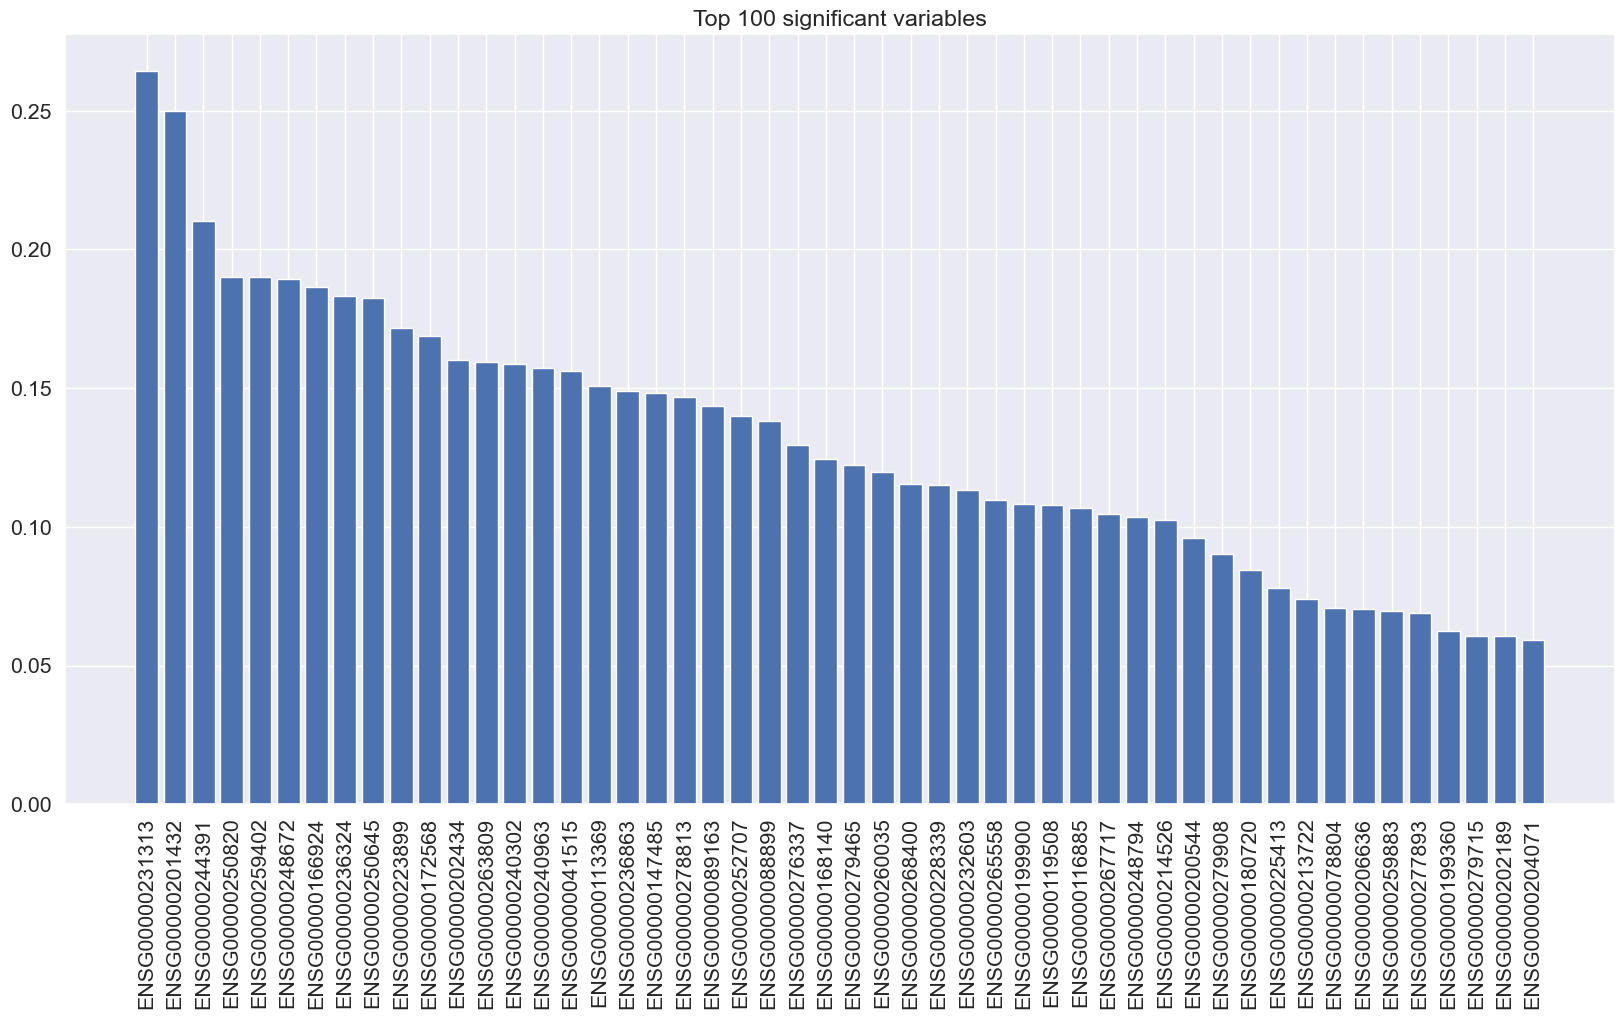

[0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
[1 1 1 1 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1
 1 0 0 1 1 1 1 0 1 0 0 1 1 1 1 0 1 1 1 1 1 0 1 1 1 0 1 1 1 0 1 1 1 1 1 1 1]


<Axes: >

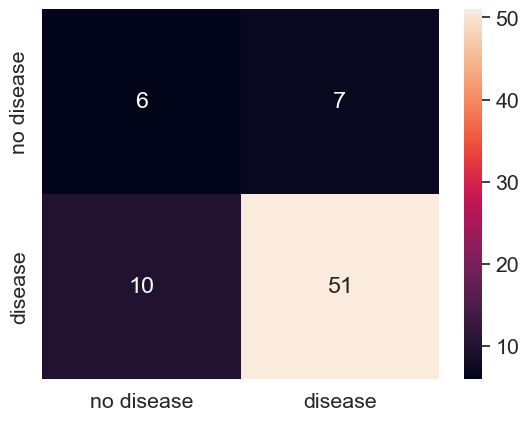

In [57]:
# perform cross-validation for the best model
lr = LogisticRegression(
    **gs_model.best_params_,
    penalty='l1',
    class_weight='balanced',
    solver='liblinear'
)
scores = cross_val_score(
    lr, X_std, y_disease, cv=5, scoring='roc_auc'
)
preds = cross_val_predict(
    lr, X_std, y_disease, cv=5, method='predict'
)

print("predsa", preds)

print(scores)
print("roc_auc: %0.2f +/- %0.2f" % (scores.mean(), scores.std()))

features = (RNA.lazy()
            .select(["GENE_ID"])
            .collect()).to_numpy().flatten()
features

d = np.column_stack((features, abs(model.coef_[0])))
significant_varsl1 = d[d[:, 1].argsort()][::-1]
# barplot of the top 50 significant variables
plt.figure(figsize=(20, 10))
plt.bar(significant_varsl1[:50, 0], significant_varsl1[:50, 1])
plt.xticks(rotation=90)
plt.title("Top 100 significant variables")
plt.show()

# y_pred = model.predict(X_std)

print(y_disease)
print(preds)

cmtx = confusion_matrix(y_disease, preds, labels=[0,1])

df_cm = pd.DataFrame(cmtx, columns=["no disease", "disease"])
df_cm.index = ["no disease", "disease"]
sn.set(font_scale=1.4) # for label size
sn.heatmap(df_cm, annot=True) # font size